# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [3]:
# Your code here
## Part A
print(f"A) The shape of the dataset is: {penguins.shape}")

## Part B
print(f"\nB) The columns in the dataset are: {penguins.columns.tolist()}")

## Part C
print(f"\nC) The number of missing values in each column are:\n{penguins.isnull().sum()}")

## Part D
print("\nD) The following is the number of penguins in each species:")
print(penguins["species"].groupby(penguins["species"]).count())
print("\nThe following is the number of male/female penguins:")
print(penguins["sex"].groupby(penguins["sex"]).count())

A) The shape of the dataset is: (344, 8)

B) The columns in the dataset are: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']

C) The number of missing values in each column are:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

D) The following is the number of penguins in each species:
species
Adelie       152
Chinstrap     68
Gentoo       124
Name: species, dtype: int64

The following is the number of male/female penguins:
sex
female    165
male      168
Name: sex, dtype: int64


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [4]:
# Your code here
penguins_clean = penguins.copy().dropna()
print(f"The shape of the dataset is: {penguins_clean.shape}")

The shape of the dataset is: (333, 8)


### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [5]:
# Your code here
for column in penguins_clean.columns:
    if penguins_clean[column].dtype in ["int64", "float64"]:
        print(f"{column}\n{penguins_clean[column].describe()}\n")

bill_length_mm
count    333.000
mean      43.993
std        5.469
min       32.100
25%       39.500
50%       44.500
75%       48.600
max       59.600
Name: bill_length_mm, dtype: float64

bill_depth_mm
count    333.000
mean      17.165
std        1.969
min       13.100
25%       15.600
50%       17.300
75%       18.700
max       21.500
Name: bill_depth_mm, dtype: float64

flipper_length_mm
count    333.000
mean     200.967
std       14.016
min      172.000
25%      190.000
50%      197.000
75%      213.000
max      231.000
Name: flipper_length_mm, dtype: float64

body_mass_g
count     333.000
mean     4207.057
std       805.216
min      2700.000
25%      3550.000
50%      4050.000
75%      4775.000
max      6300.000
Name: body_mass_g, dtype: float64

year
count     333.000
mean     2008.042
std         0.813
min      2007.000
25%      2007.000
50%      2008.000
75%      2009.000
max      2009.000
Name: year, dtype: float64



### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [ ]:
# Your code here
species_sex_mean = penguins_clean.groupby(["species", "sex"]
    ).mean(numeric_only = True)[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
species_sex_count = penguins_clean.groupby(["species", "sex"]
    ).count()[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
print(f"A) The following is the mean for each (species, sex) combination:")
display(species_sex_mean)
print(f"\nThe following is the count for each (species, sex) combination:")
display(species_sex_count)

print(f"\nB) (Gentoo, male) is the combination with the largest average body_mass_g:")
print(species_sex_mean.sort_values("body_mass_g", ascending = False).iloc[0])

A) The following is the mean for each (species, sex) combination:


bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    female          37.258         17.622            187.795   
          male            40.390         19.073            192.411   
Chinstrap female          46.574         17.588            191.735   
          male            51.094         19.253            199.912   
Gentoo    female          45.564         14.238            212.707   
          male            49.474         15.718            221.541   

                  body_mass_g  
species   sex                  
Adelie    female     3368.836  
          male       4043.493  
Chinstrap female     3527.206  
          male       3938.971  
Gentoo    female     4679.741  
          male       5484.836


The following is the count for each (species, sex) combination:


bill_length_mm  bill_depth_mm  flipper_length_mm  \
species   sex                                                        
Adelie    female              73             73                 73   
          male                73             73                 73   
Chinstrap female              34             34                 34   
          male                34             34                 34   
Gentoo    female              58             58                 58   
          male                61             61                 61   

                  body_mass_g  
species   sex                  
Adelie    female           73  
          male             73  
Chinstrap female           34  
          male             34  
Gentoo    female           58  
          male             61


B) (Gentoo, male) is the combination with the largest average body_mass_g:
bill_length_mm         49.474
bill_depth_mm          15.718
flipper_length_mm     221.541
body_mass_g          5484.836
Name: (Gentoo, male), dtype: float64


### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [12]:
# Your code here
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "year"]

print("A) The following is the correlation matrix among numeric columns:")
print(penguins_clean[numeric_cols].corr())

print("\nB) The following is the correlation matrix within each species:")
print(penguins_clean.groupby("species").corr(numeric_only = True))

A) The following is the correlation matrix among numeric columns:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.229              0.653   
bill_depth_mm              -0.229          1.000             -0.578   
flipper_length_mm           0.653         -0.578              1.000   
body_mass_g                 0.589         -0.472              0.873   
year                        0.033         -0.048              0.151   

                   body_mass_g   year  
bill_length_mm           0.589  0.033  
bill_depth_mm           -0.472 -0.048  
flipper_length_mm        0.873  0.151  
body_mass_g              1.000  0.022  
year                     0.022  1.000  

B) The following is the correlation matrix within each species:
                             bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.

C) An example of Simpson's Paradox would be with the variables: bill_depth_mm & flipper_length_mm. We can observe from the correlation plot that the aggregate correlation between the two is -0.578. However, the subgroup correlations for Adelie, Chinstrap, and Gentoo are +0.311, +0.580, and +0.711 respectively.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


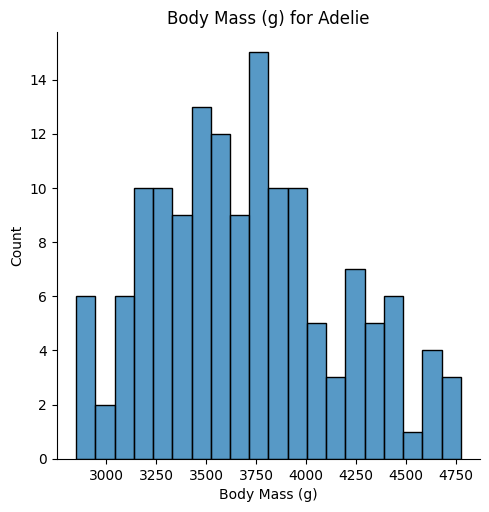

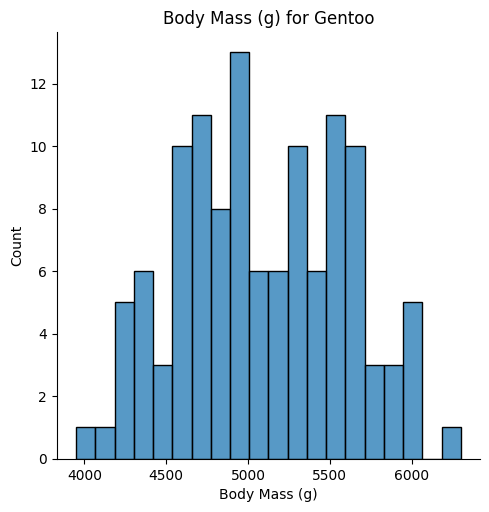

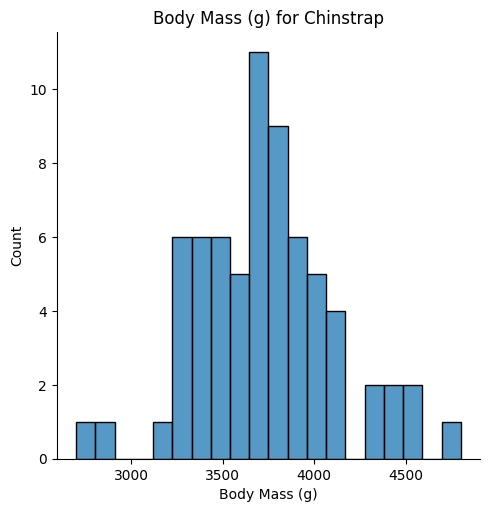

In [8]:
for species in penguins_clean["species"].unique():
    sns.displot(penguins_clean[penguins_clean["species"] == species], x = "body_mass_g", bins = 20)
    plt.title(f"Body Mass (g) for {species}")
    plt.xlabel("Body Mass (g)")
    plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

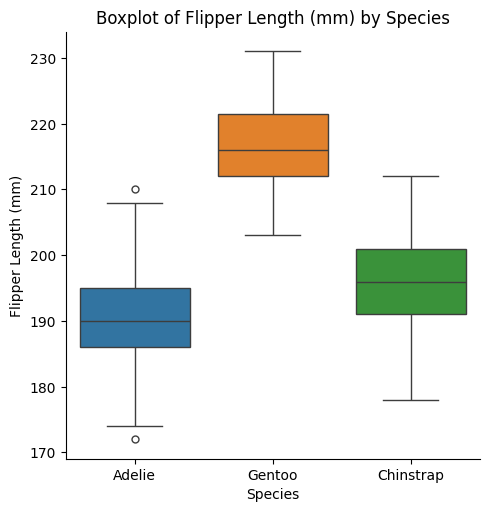

In [9]:
sns.catplot(data = penguins_clean, x = "species", y = "flipper_length_mm", kind = "box", hue = "species")
plt.title("Boxplot of Flipper Length (mm) by Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")
plt.show()

From largest to smallest, the order of the flipper length in mm starts with Gentoo, then Chinstrap, and lastly Adelie. There is some overlap between the Chinstrap and Adelie species, but Gentoo is clear from any overlap. We approximate that the IQR for all 3 species are relatively similar in magnitude. Additionally, Adelie is the only species with apparent outliers in its distribution.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

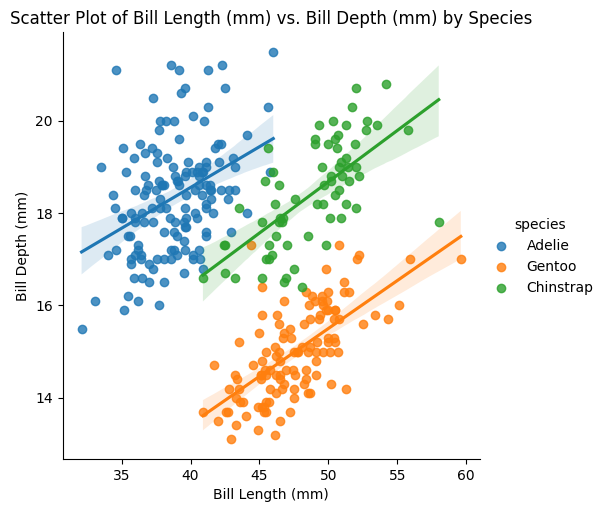

In [10]:
sns.lmplot(data = penguins_clean, x = "bill_length_mm", y = "bill_depth_mm", hue = "species")
plt.title("Scatter Plot of Bill Length (mm) vs. Bill Depth (mm) by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

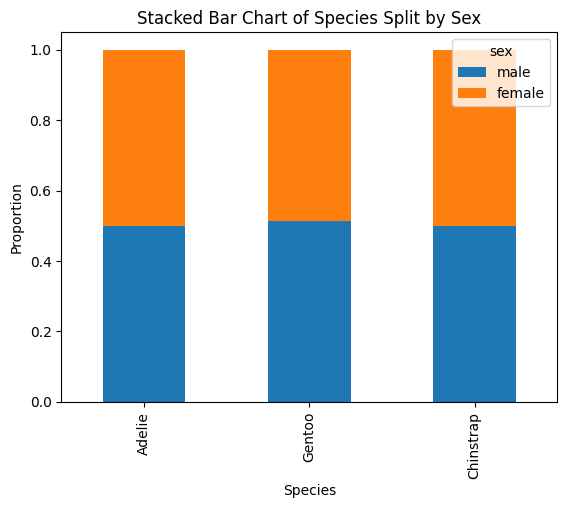

In [11]:
count = penguins_clean[["species", "sex"]].value_counts(normalize = True)
count = count.unstack()
proportion = count.div(count.sum(axis = 1), axis = 0)
proportion.plot(kind = "bar", stacked = True)
plt.title("Stacked Bar Chart of Species Split by Sex")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.show()